# Part 1: Nédélec 有限元求解 curl curl u + u = f (NGSolve 环境)

## 问题描述

在 2D L-shape 域 $\Omega = [-1,1]^2 \setminus [0,1] \times [-1,0]$ 上，使用 **Nédélec (edge) 元** 求解 $H(\mathrm{curl})$ 问题：

$$\begin{cases}
\mathrm{curl}\,\mathrm{curl}\,\mathbf{u} + \mathbf{u} = \mathbf{f} & \text{in } \Omega \\
\mathbf{u} \cdot \mathbf{t} = 0 & \text{on } \partial\Omega
\end{cases}$$

其中 $\mathbf{t}$ 是边界单位切向量。在 2D 中：

$$\mathrm{curl}\,\mathbf{u} = \frac{\partial u_2}{\partial x} - \frac{\partial u_1}{\partial y} \quad (\text{标量})$$

$$\mathrm{curl}\,\phi = \left(\frac{\partial \phi}{\partial y},\, -\frac{\partial \phi}{\partial x}\right) \quad (\text{标量} \to \text{向量})$$

### 弱形式 (Nédélec 边元)

$\mathbf{u}, \mathbf{v} \in H_0(\mathrm{curl};\Omega)$，求 $\mathbf{u}_h$ 使得：

$$(\mathrm{curl}\,\mathbf{u}_h,\, \mathrm{curl}\,\mathbf{v}_h) + (\mathbf{u}_h,\, \mathbf{v}_h) = (\mathbf{f},\, \mathbf{v}_h), \quad \forall \mathbf{v}_h \in V_h$$

其中 $V_h = \mathrm{ND}_p(\mathcal{T}_h) \cap H_0(\mathrm{curl};\Omega)$ 为 Nédélec 有限元空间，$H_0(\mathrm{curl};\Omega)$ 中的函数满足 $\mathbf{u} \cdot \mathbf{t} = 0$ on $\partial\Omega$。

### 本 Notebook 的任务

1. 用 NGSolve 的 Nédélec 有限元严格求解，生成 Ground Truth
2. 采样 FEM 解的点值，保存为 `.npz` 文件供 PINN notebook 使用
3. 在规则网格上评估 FEM 解，保存网格数据供对比可视化

> **环境要求**: 本 notebook 仅需 `ngsolve`, `netgen`, `numpy`, `matplotlib`，不需要 PyTorch。

In [28]:
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.geom2d import SplineGeometry
import numpy as np

# ===================== 1. 构造 L-shape 域 (带凹角处局部加密) =====================
geo = SplineGeometry()
pnts = [
    (-1, -1),  # 0
    (0, -1),   # 1
    (0, 0),    # 2  (re-entrant corner)
    (1, 0),    # 3
    (1, 1),    # 4
    (-1, 1),   # 5
]
p = [geo.AppendPoint(*pt) for pt in pnts]

geo.Append(["line", p[0], p[1]], bc="bottom")
geo.Append(["line", p[1], p[2]], bc="reentrant_v")
geo.Append(["line", p[2], p[3]], bc="reentrant_h")
geo.Append(["line", p[3], p[4]], bc="right")
geo.Append(["line", p[4], p[5]], bc="top")
geo.Append(["line", p[5], p[0]], bc="left")

ngmesh = geo.GenerateMesh(maxh=0.05)

# 凹角 (0,0) 附近局部加密，提高奇性区域精度
ngmesh.Refine()  # 全局加密一次使网格足够精细
mesh = Mesh(ngmesh)
print(f"Mesh elements: {mesh.ne}, vertices: {mesh.nv}")
Draw(mesh)


Mesh elements: 10968, vertices: 5645


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [29]:
# ===================== 2. Nédélec 有限元空间与严格求解 =====================
#
# 使用 Nédélec 第一类边元 (NGSolve 中 HCurl 空间即 Nédélec 元)
# 
# 问题: curl curl u + u = f, 在 L-shape 域上
# 边界条件: u × n = 0 on ∂Ω (即切向分量为零, PEC边界条件)
#
# Nédélec 元的关键特征:
#   - 自由度定义在边(棱)上, 是切向分量的矩
#   - 自然满足 H(curl) 正则性
#   - dirichlet BC 在 NGSolve 中约束的恰好是切向分量 u·t = 0

order = 3  # Nédélec 元阶次 (2阶对于 L-shape 域已足够精确)

# 构建 HCurl 有限元空间 (即 Nédélec 空间)
# dirichlet=".*" 表示所有边界上施加 u×n = 0
fes = HCurl(mesh, order=order, dirichlet=".*")
print(f"Nédélec (HCurl) space: order={order}, ndof={fes.ndof}")

u, v = fes.TnT()


Nédélec (HCurl) space: order=3, ndof=158385


In [30]:
# ===================== 3. 右端项与弱形式组装求解 =====================

# 右端项 f = (sin(πy), sin(πx)) 
# 这是一个光滑的 source term, 但因为 L-shape 域的凹角,
# 精确解 u 在 (0,0) 处会有奇性 (u ∈ H^s(curl), s < 1)
f_source = CoefficientFunction((
    sin(pi * y),
    sin(pi * x)
))

# Nédélec 弱形式: (curl u, curl v) + (u, v) = (f, v)
# 在 2D 中: curl u (标量) = ∂u₂/∂x - ∂u₁/∂y
#           curl curl u (向量) = (∂(curl u)/∂y, -∂(curl u)/∂x)
a = BilinearForm(fes)
a += (curl(u) * curl(v) + u * v) * dx

L = LinearForm(fes)
L += f_source * v * dx

# 求解
gfu = GridFunction(fes)
with TaskManager():
    a.Assemble()
    L.Assemble()
    # 使用直接求解器 (sparse Cholesky)
    gfu.vec.data = a.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky") * L.vec

print("Nédélec FEM solve complete!")


Nédélec FEM solve complete!


In [31]:
# ===================== 4. 求解后验证：残差检查与 H(curl) 范数 =====================

# 计算弱残差: r(v) = (f,v) - (curl u_h, curl v) - (u_h, v) 
# 在离散空间内, 由于 Galerkin 正交性, 这应该 ≈ 0
res_form = LinearForm(fes)
res_form += (f_source * v - curl(gfu) * curl(v) - gfu * v) * dx
res_form.Assemble()
res_norm = sqrt(abs(InnerProduct(res_form.vec, gfu.vec)))
print(f"Weak residual check (should be ~0): {res_norm:.6e}")

# 计算解的 H(curl) 范数
hcurl_norm = sqrt(Integrate(curl(gfu)**2 + gfu*gfu, mesh))
print(f"||u_h||_H(curl) = {hcurl_norm:.6f}")
print(f"||u_h||_L2 = {sqrt(Integrate(gfu*gfu, mesh)):.6f}")
print(f"||curl u_h||_L2 = {sqrt(Integrate(curl(gfu)**2, mesh)):.6f}")


Weak residual check (should be ~0): 2.052328e-08
||u_h||_H(curl) = 0.525356
||u_h||_L2 = 0.159348
||curl u_h||_L2 = 0.500607


In [32]:
# ===================== 5. 可视化 Nédélec FEM 解 =====================
Draw(gfu, mesh, "u_nedelec")
Draw(curl(gfu), mesh, "curl_u_nedelec")
Draw(Norm(gfu), mesh, "u_norm_nedelec")


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [33]:
# ===================== 6. 导出 VTK 文件 =====================
vtk = VTKOutput(mesh,
                coefs=[gfu, curl(gfu), Norm(gfu)],
                names=["u_vec", "curl_u", "u_norm"],
                filename="curlcurl_fem_result",
                subdivision=2)
vtk.Do()
print("VTK exported: curlcurl_fem_result.vtu")


VTK exported: curlcurl_fem_result.vtu


In [34]:
# ===================== 7. 采样 FEM 解并保存为 .npz 文件 =====================

def sample_fem_solution(gfu, f_source, n_interior=8000, n_boundary=2000):
    """
    从 Nédélec FEM 解中采样点值.
    
    注意: Nédélec 元的解 gfu 在 NGSolve 中可以直接按分量评估,
    gfu(mp) 返回 (u_x, u_y), 这是 Cartesian 分量, 不是边基函数系数.
    
    采样内容:
      - interior_pts: 内部配置点坐标
      - interior_u: u_h 在配置点的值 (Cartesian 分量)
      - interior_f: f 在配置点的值
      - boundary_pts: 边界点坐标
      - boundary_u: u_h 在边界点的值 (应满足 u·t ≈ 0)
    """
    mesh = gfu.space.mesh
    interior_pts, interior_u, interior_f = [], [], []
    count, attempts = 0, 0
    
    while count < n_interior and attempts < n_interior * 5:
        px = np.random.uniform(-1, 1)
        py = np.random.uniform(-1, 1)
        # 排除 L-shape 域缺失的第四象限
        if px > 0 and py < 0:
            attempts += 1
            continue
        # 避免恰好在边界上的点 (留一点 margin)
        eps = 1e-6
        if abs(px - 1) < eps or abs(px + 1) < eps or abs(py - 1) < eps or abs(py + 1) < eps:
            attempts += 1
            continue
        if abs(px) < eps and py < eps:  # 凹角附近边界
            attempts += 1
            continue
        try:
            mp = mesh(px, py)
            val = gfu(mp)      # 返回 (u_x, u_y) Cartesian 分量
            f_val = f_source(mp)
            interior_pts.append([px, py])
            interior_u.append([val[0], val[1]])
            interior_f.append([f_val[0], f_val[1]])
            count += 1
        except:
            pass
        attempts += 1
    
    # 边界采样: 在各边上均匀采样
    boundary_pts, boundary_u = [], []
    edges = [
        ((-1, -1), (0, -1),  n_boundary // 6),   # bottom
        ((0, -1),  (0, 0),   n_boundary // 6),    # reentrant_v
        ((0, 0),   (1, 0),   n_boundary // 6),    # reentrant_h
        ((1, 0),   (1, 1),   n_boundary // 6),    # right
        ((1, 1),   (-1, 1),  n_boundary // 6),    # top
        ((-1, 1),  (-1, -1), n_boundary // 6),    # left
    ]
    for (x0, y0), (x1, y1), n in edges:
        for _ in range(n):
            t = np.random.uniform(0.01, 0.99)  # 避免角点
            px, py = x0 + t * (x1 - x0), y0 + t * (y1 - y0)
            try:
                mp = mesh(px, py)
                val = gfu(mp)
                boundary_pts.append([px, py])
                boundary_u.append([val[0], val[1]])
            except:
                pass
    
    x_int = np.array(interior_pts)
    u_int = np.array(interior_u)
    f_int = np.array(interior_f)
    x_bnd = np.array(boundary_pts)
    u_bnd = np.array(boundary_u)
    
    print(f"Sampled {len(x_int)} interior, {len(x_bnd)} boundary points")
    
    # 验证: 边界点上切向分量应该接近 0
    max_bc_tangential = 0.0
    for i, ((x0, y0), (x1, y1), _) in enumerate(edges):
        tx, ty = x1 - x0, y1 - y0
        tn = np.sqrt(tx**2 + ty**2)
        tx, ty = tx / tn, ty / tn
        start_idx = sum(e[2] for e in edges[:i])
        end_idx = start_idx + edges[i][2]
        if end_idx <= len(u_bnd):
            for j in range(start_idx, min(end_idx, len(u_bnd))):
                tang_val = abs(u_bnd[j][0] * tx + u_bnd[j][1] * ty)
                max_bc_tangential = max(max_bc_tangential, tang_val)
    print(f"Max tangential component on boundary: {max_bc_tangential:.6e} (should be ~0)")
    
    return x_int, u_int, f_int, x_bnd, u_bnd

x_int, u_int, f_int, x_bnd, u_bnd = sample_fem_solution(gfu, f_source, 10000, 3000)

# 保存采样数据 (PINN 训练用)
np.savez("fem_curlcurl_data.npz",
         x_int=x_int, u_int=u_int, f_int=f_int,
         x_bnd=x_bnd, u_bnd=u_bnd)
print("Saved fem_curlcurl_data.npz")


Sampled 10000 interior, 3000 boundary points
Max tangential component on boundary: 4.659168e-19 (should be ~0)
Saved fem_curlcurl_data.npz


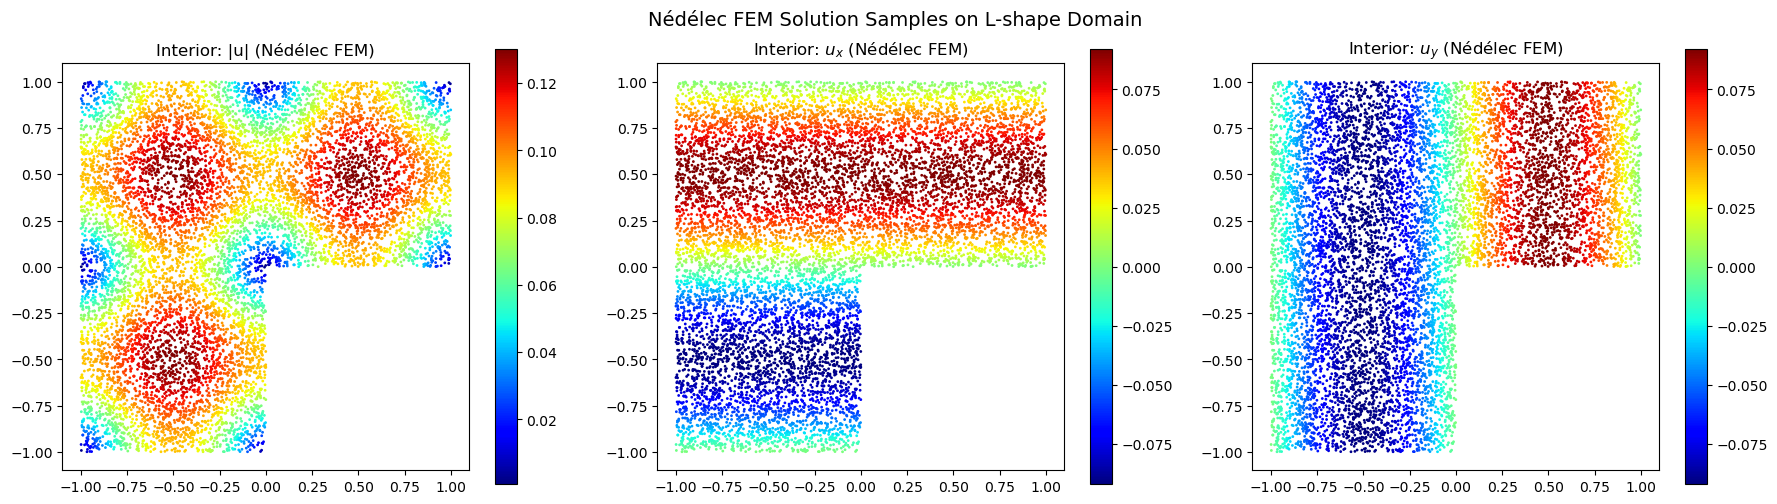

In [35]:
# ===================== 8. 可视化采样点 + 规则网格评估并保存 =====================
import matplotlib.pyplot as plt

# --- 8a. 可视化采样点 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc0 = axes[0].scatter(x_int[:,0], x_int[:,1], c=np.sqrt(u_int[:,0]**2+u_int[:,1]**2), s=1, cmap='jet')
axes[0].set_title('Interior: |u| (Nédélec FEM)'); axes[0].set_aspect('equal'); plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(x_int[:,0], x_int[:,1], c=u_int[:,0], s=1, cmap='jet')
axes[1].set_title(r'Interior: $u_x$ (Nédélec FEM)'); axes[1].set_aspect('equal'); plt.colorbar(sc1, ax=axes[1])

sc2 = axes[2].scatter(x_int[:,0], x_int[:,1], c=u_int[:,1], s=1, cmap='jet')
axes[2].set_title(r'Interior: $u_y$ (Nédélec FEM)'); axes[2].set_aspect('equal'); plt.colorbar(sc2, ax=axes[2])

plt.suptitle('Nédélec FEM Solution Samples on L-shape Domain', fontsize=14)
plt.tight_layout(); plt.show()


In [36]:
# --- 8b. 在规则网格上评估 FEM 解, 保存供 PINN notebook 对比用 ---

def evaluate_fem_on_grid(gfu, x_range, y_range, n_grid=120):
    """在规则网格上评估 Nédélec FEM 解, L-shape 缺失区域设为 NaN"""
    msh = gfu.space.mesh
    xv = np.linspace(x_range[0], x_range[1], n_grid)
    yv = np.linspace(y_range[0], y_range[1], n_grid)
    X, Y = np.meshgrid(xv, yv)
    mask = (X > 0) & (Y < 0)
    ux_f = np.full_like(X, np.nan)
    uy_f = np.full_like(X, np.nan)
    for i in range(n_grid):
        for j in range(n_grid):
            if X[i,j] > 0 and Y[i,j] < 0:
                continue
            try:
                mp = msh(X[i,j], Y[i,j])
                val = gfu(mp)
                ux_f[i,j], uy_f[i,j] = val[0], val[1]
            except:
                pass
    umag_f = np.sqrt(np.nan_to_num(ux_f)**2 + np.nan_to_num(uy_f)**2)
    umag_f[mask] = np.nan
    return X, Y, ux_f, uy_f, umag_f

# 全域网格评估
print('Evaluating FEM on full grid [-1,1]² ...')
ng = 100
Xf, Yf, uxf, uyf, uf = evaluate_fem_on_grid(gfu, (-1, 1), (-1, 1), ng)

# Zoom 凹角评估
print('Evaluating FEM on zoom grid [-0.2,0.2]² ...')
nz = 100
Xfz, Yfz, uxfz, uyfz, ufz = evaluate_fem_on_grid(gfu, (-0.2, 0.2), (-0.2, 0.2), nz)

# 保存网格评估数据 (PINN notebook 对比可视化用, 完全不需要 ngsolve)
np.savez("fem_grid_data.npz",
         # 全域网格
         Xf=Xf, Yf=Yf, uxf=uxf, uyf=uyf, uf=uf,
         # Zoom 网格
         Xfz=Xfz, Yfz=Yfz, uxfz=uxfz, uyfz=uyfz, ufz=ufz)
print("Saved fem_grid_data.npz")
print("Done! 所有数据已保存, 可在 PINN_curlcurl.ipynb 中使用 (无需 ngsolve).")


Evaluating FEM on full grid [-1,1]² ...
Evaluating FEM on zoom grid [-0.2,0.2]² ...
Saved fem_grid_data.npz
Done! 所有数据已保存, 可在 PINN_curlcurl.ipynb 中使用 (无需 ngsolve).
